In [1]:
import mne
mne.set_log_level('error')

import numpy as np
import matplotlib.pyplot as plt
import glob

In [2]:
# Import raw data
glob.glob('Raw/Sub_1/Subject 1*')

['Raw/Sub_1\\Subject 1, Session 1, Block 1 Recording_FLEX2_213075_2025.01.25T15.18.28.08.00.json',
 'Raw/Sub_1\\Subject 1, Session 1, Block 1 Recording_FLEX2_213075_2025.01.25T15.18.28.08.00.md.edf']

In [4]:
raw = mne.io.read_raw_edf('Raw/Sub_1/Subject 1, Session 1, Block 1 Recording_FLEX2_213075_2025.01.25T15.18.28.08.00.md.edf',preload=True)

In [5]:
raw.info

<Info | 8 non-empty values
 bads: []
 ch_names: TimestampS, TimestampMs, OrTimestampS, OrTimestampMs, Counter, ...
 chs: 127 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 128.0 Hz
 meas_date: 2025-01-25 15:18:28 UTC
 nchan: 127
 projs: []
 sfreq: 256.0 Hz
 subject_info: <subject_info | his_id: X, sex: 0, last_name: X>
>

In [6]:
raw.info['ch_names']

['TimestampS',
 'TimestampMs',
 'OrTimestampS',
 'OrTimestampMs',
 'Counter',
 'Interpolated',
 'Cz',
 'FCz',
 'Afz',
 'Fp1',
 'F5',
 'F1',
 'CP5',
 'CP3',
 'CP1',
 'P1',
 'P3',
 'P5',
 'P7',
 'PO7',
 'PO3',
 'O1',
 'Pz',
 'POz',
 'Oz',
 'O2',
 'PO4',
 'PO8',
 'P8',
 'P6',
 'P4',
 'P2',
 'CP2',
 'CP4',
 'CP6',
 'F2',
 'F6',
 'Fp2',
 'RawCq',
 'Battery',
 'BatteryPercent',
 'FwBufferSize',
 'FwClockTime',
 'MarkerHardware',
 'CQ.Cz',
 'CQ.FCz',
 'CQ.Afz',
 'CQ.Fp1',
 'CQ.F5',
 'CQ.F1',
 'CQ.CP5',
 'CQ.CP3',
 'CQ.CP1',
 'CQ.P1',
 'CQ.P3',
 'CQ.P5',
 'CQ.P7',
 'CQ.PO7',
 'CQ.PO3',
 'CQ.O1',
 'CQ.Pz',
 'CQ.POz',
 'CQ.Oz',
 'CQ.O2',
 'CQ.PO4',
 'CQ.PO8',
 'CQ.P8',
 'CQ.P6',
 'CQ.P4',
 'CQ.P2',
 'CQ.CP2',
 'CQ.CP4',
 'CQ.CP6',
 'CQ.F2',
 'CQ.F6',
 'CQ.Fp2',
 'CQ.Overall',
 'EQ.SampleRateQua',
 'EQ.OVERALL',
 'EQ.Cz',
 'EQ.FCz',
 'EQ.Afz',
 'EQ.Fp1',
 'EQ.F5',
 'EQ.F1',
 'EQ.CP5',
 'EQ.CP3',
 'EQ.CP1',
 'EQ.P1',
 'EQ.P3',
 'EQ.P5',
 'EQ.P7',
 'EQ.PO7',
 'EQ.PO3',
 'EQ.O1',
 'EQ.Pz',
 'EQ.POz'

In [7]:
raw.__dict__

{'_last_samps': array([76031]),
 '_first_samps': array([0]),
 'info': <Info | 8 non-empty values
  bads: []
  ch_names: TimestampS, TimestampMs, OrTimestampS, OrTimestampMs, Counter, ...
  chs: 127 EEG
  custom_ref_applied: False
  highpass: 0.0 Hz
  lowpass: 128.0 Hz
  meas_date: 2025-01-25 15:18:28 UTC
  nchan: 127
  projs: []
  sfreq: 256.0 Hz
  subject_info: <subject_info | his_id: X, sex: 0, last_name: X>
 >,
 'buffer_size_sec': 1.0,
 '_cals': array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 

In [23]:
# To set target channels
target_channels = [
    'Cz', 'FCz', 'Afz', 'Fp1', 'F5', 'F1', 'CP5', 'CP3', 'CP1', 'P1', 
    'P3', 'P5', 'P7', 'PO7', 'PO3', 'O1', 'Pz', 'POz', 'Oz', 'O2', 
    'PO4', 'PO8', 'P8', 'P6', 'P4', 'P2', 'CP2', 'CP4', 'CP6', 'F2', 
    'F6', 'Fp2'
]

raw.pick_channels(target_channels)

<RawEDF | Subject 1, Session 1, Block 1 Recording_FLEX2_213075_2025.01.25T15.18.28.08.00.md.edf, 32 x 76032 (297.0 s), ~18.6 MiB, data loaded>

In [ ]:
raw.plot(duration = 1);
plt.show()

In [26]:
# Rename channel to standard
raw.rename_channels({'Afz': 'AFz'})

<RawEDF | Subject 1, Session 1, Block 1 Recording_FLEX2_213075_2025.01.25T15.18.28.08.00.md.edf, 32 x 76032 (297.0 s), ~18.6 MiB, data loaded>

In [30]:
raw.set_montage('standard_1020')

<RawEDF | Subject 1, Session 1, Block 1 Recording_FLEX2_213075_2025.01.25T15.18.28.08.00.md.edf, 32 x 76032 (297.0 s), ~18.6 MiB, data loaded>

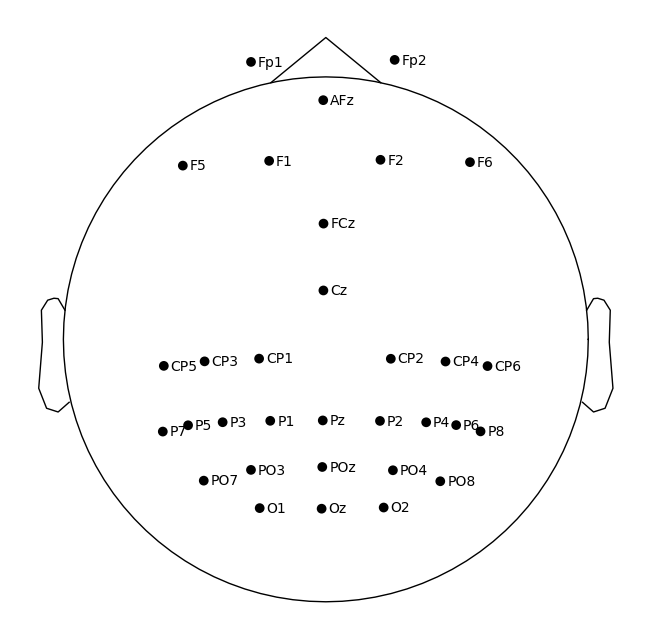

In [33]:
raw.plot_sensors(show_names=True);

In [34]:
mne.events_from_annotations(raw)

(array([[  116,     0,   569],
        [  172,     0,  1037],
        [  223,     0,   550],
        ...,
        [75592,     0,   784],
        [75644,     0,   662],
        [75991,     0,    18]], shape=(1071, 3)),
 {np.str_('behav,2,-1,103'): 1,
  np.str_('behav,2,-1,465'): 2,
  np.str_('behav,2,-1,801'): 3,
  np.str_('behav,2,-1,822'): 4,
  np.str_('behav,2,-1,885'): 5,
  np.str_('behav,2,-1,906'): 6,
  np.str_('behav,3,-1,1011'): 7,
  np.str_('behav,3,-1,1032'): 8,
  np.str_('behav,3,-1,1053'): 9,
  np.str_('behav,3,-1,124'): 10,
  np.str_('behav,3,-1,145'): 11,
  np.str_('behav,3,-1,166'): 12,
  np.str_('behav,3,-1,187'): 13,
  np.str_('behav,3,-1,208'): 14,
  np.str_('behav,3,-1,21'): 15,
  np.str_('behav,3,-1,229'): 16,
  np.str_('behav,3,-1,250'): 17,
  np.str_('behav,3,-1,271'): 18,
  np.str_('behav,3,-1,276'): 19,
  np.str_('behav,3,-1,297'): 20,
  np.str_('behav,3,-1,318'): 21,
  np.str_('behav,3,-1,339'): 22,
  np.str_('behav,3,-1,360'): 23,
  np.str_('behav,3,-1,381'): 2

c:\Users\Sam\anaconda3\envs\neural_data_science\Lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


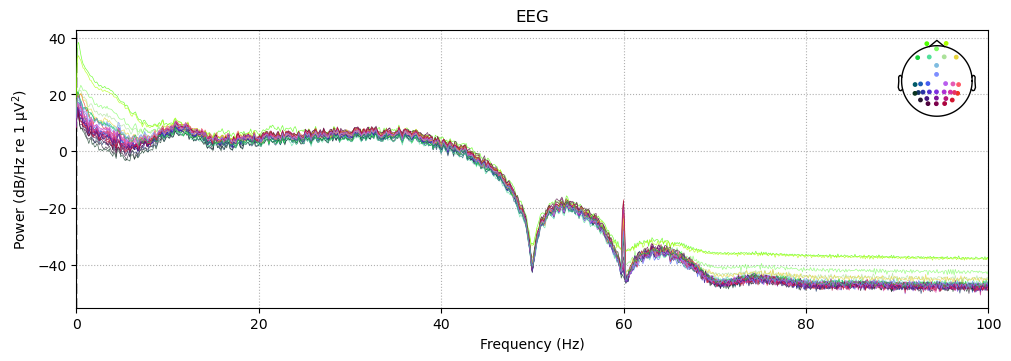

In [36]:
raw.plot_psd(fmax=100);

In [ ]:
# set parameters
low_cut = 0.1
hi_cut = 30

raw_filt = raw.copy().filter(low_cut, hi_cut)